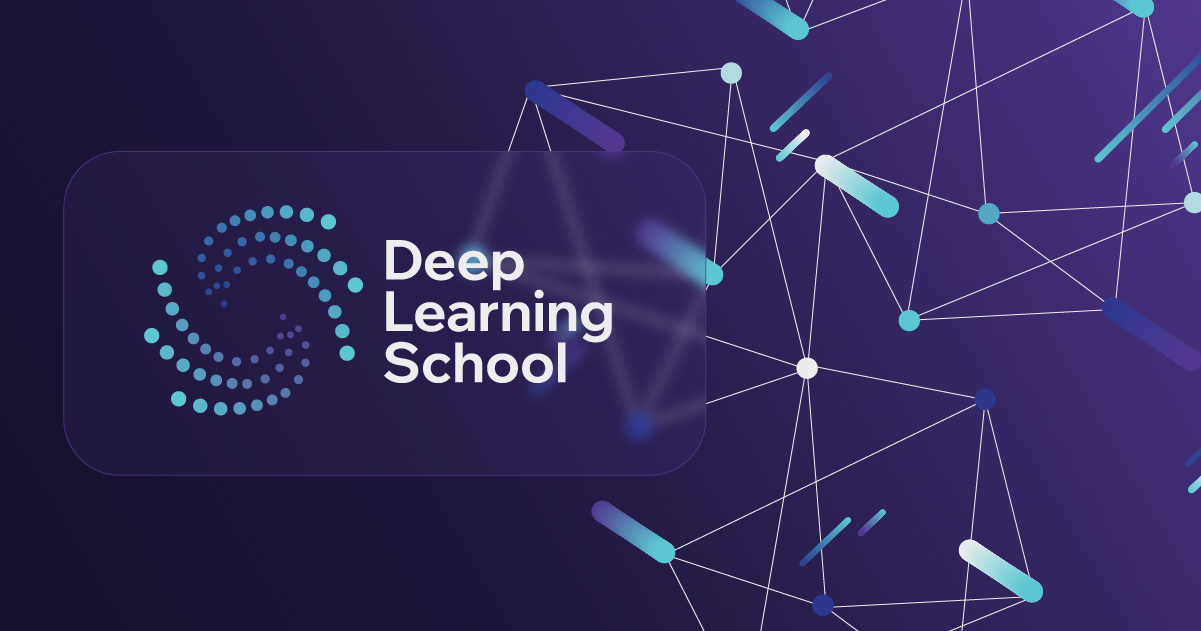


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 991 картинка, для которых вам будет необходимо предсказать класс.

## Шаг 1. Установка зависимостей

####Установим необходимые библиотеки и проверим доступность CUDA

In [1]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np
import pandas as pd
import google.colab

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
!nvidia-smi

Thu Apr 30 12:54:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import pickle
import numpy as np
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path


from torchvision import models
from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

import random
import shutil
from collections import defaultdict

#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [4]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.13
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


Сверим с версиями питона и библиотек, на которых работал эталонный ноутбук:

- Python 3.12.12
- torch version: 2.8.0+cu126
- torchvision version: 0.23.0+cu126
- tqdm version: 4.67.1
- matplotlib version: 3.10.0
- seaborn version: 0.13.2
- Pillow version: 11.3.0


 #### Определим константы, которые будем использовать в по ходу ноутбука

In [5]:
# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path('/content/train') #Path('./data/train/')
TEST_DIR = Path('/content/testset') #Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

Уменьшаем случайность для воспроизводимости

In [6]:
SEED = 42

# PyTorch
torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # For multi-GPU setups

# NumPy
np.random.seed(SEED)

# Python's built-in random
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [7]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=926b3047-599e-4666-a119-0737734cf5ec
To: /content/journey-springfield.zip
100% 546M/546M [00:09<00:00, 60.2MB/s]


In [8]:
!unzip -q /content/journey-springfield.zip

Посмотрите на структуру файлов в папках train и testset.

В train лежат данные, которые мы будем использовать для обучения модели. Изображения персонажей разложены по папкам, которые названы по именам персонажей. Названия папок мы в дальнейшем будет использовать в качестве текстовых меток классов.

В testset находятся изображения, для которых вам надо будет сделать прогноз наиболее вероятного класса.


Для обращения к файлам сформируем списки имен файлов обучающей+валидационнной и тестовой выборок. Это полные имена, включающие путь к файлам.


In [9]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

Кодировать имена персонажей в числовые метки класса и обратно будем при помощи `LabelEncoder`.

Для train выборки сформируем список текстовых меток всех изображений - имя родительской директории, которая одновременно является и именем персонажа. Зададим числовые метки классов нашего энкодера при помощи метода `fit`.

Далее будем применять метод `transform` для преобразования текстовых меток в числовые, и метод `inverse_transform` для преобразования числовых меток в текстовые.


In [10]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим train выборку на обучающую и валидационнную части. Для того, чтобы персонажи были пропорционально представлены в обучающей и валидационнной подвыборках, применим стратификацию по меткам класса.

In [11]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25, \
                                          stratify=train_val_labels, random_state=SEED)

####Создадим Datasets и Dataloaders

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:
https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/


У нас есть набор файлов-картинок, которые требуется преобразовать в тензоры, и добавить к ним числовые метки классов. Реализуем это с помощью созданного нами класса `SimpsonsDataset`, который из списка файлов создаст необходимый нам Dataset.  

Будем действовать согласно инструкции из документации (https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files):
- наш класс будет наследовать от класса Dataset
- мы переопределим методы `__init__`, `__len__` и `__getitem__`, а также для удобства добавим несколько методов для загрузки и преобразования изображений.

Важно разобраться, что делает метод self.transform_images_to_tensors().

`Compose` объединяет последовательность следующих преобразований:
- `PILToTensor` конвертирует  `PIL Image` в тензор с параметрами в диапазоне $[0, 255]$ (как все пиксели в исходном изображении)
- `ToDtype` преобразует тензор в `FloatTensor` размера ($C \times H \times W$) со значениями пикселей в диапазоне $[0,1]$
- затем `Normalize` производится масштабирование:
$\text{input} = \frac{\text{input} - \text{mean}}{\text{std}} $, <br>      где константы mean и std - средние и дисперсии по каналам в датасете ImageNet
- наконец, `Resize` преобразует картинки к размеру $224 \times 224$ (в описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следует привести их к одному размеру).

Сейчас аугментация не изображений не производится, поэтому для обучающих и валидационных/тестовых изображений производится одинаковая трансформация. В дальнейшем, если вы захотите добавить аугментацию, вы можете сделать это, например, модифицировав метод `transform_images_to_tensors`. Подробнее про трансформацию изображений вы можете почитать в документации: https://docs.pytorch.org/vision/main/transforms.html


In [12]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)

In [13]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2 )
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
loaders = {'train':train_loader, 'val': val_loader}

#### Посмотрим на изображения персонажей

Напишем функцию для визуализации картинок. Это аналог Imshow, которая будет принимать на вход тензоры

In [14]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Проверим, как работает наша функция. Возьмем один батч из лоадера и подадим на вход функции первый тензор из этого батча. Заодно посмотрим, как работает кодировщик меток класса.

Числовая метка класса: 9
Текстовая метка класса: ['comic_book_guy']


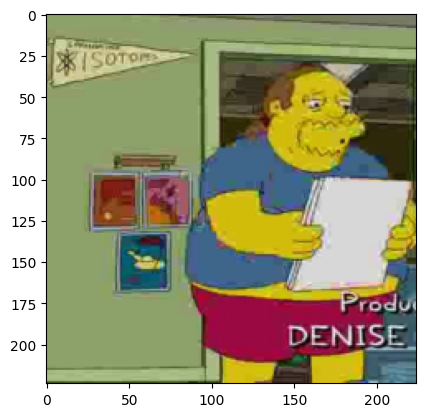

In [15]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])


In [16]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

Давайте посмотрим на наших героев внутри датасета.

In [17]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам. Очистка датасета - это один из способов повысить качество модели. Этим можно будет заняться во второй части домашнего задания.

Запустим написанную функцию.

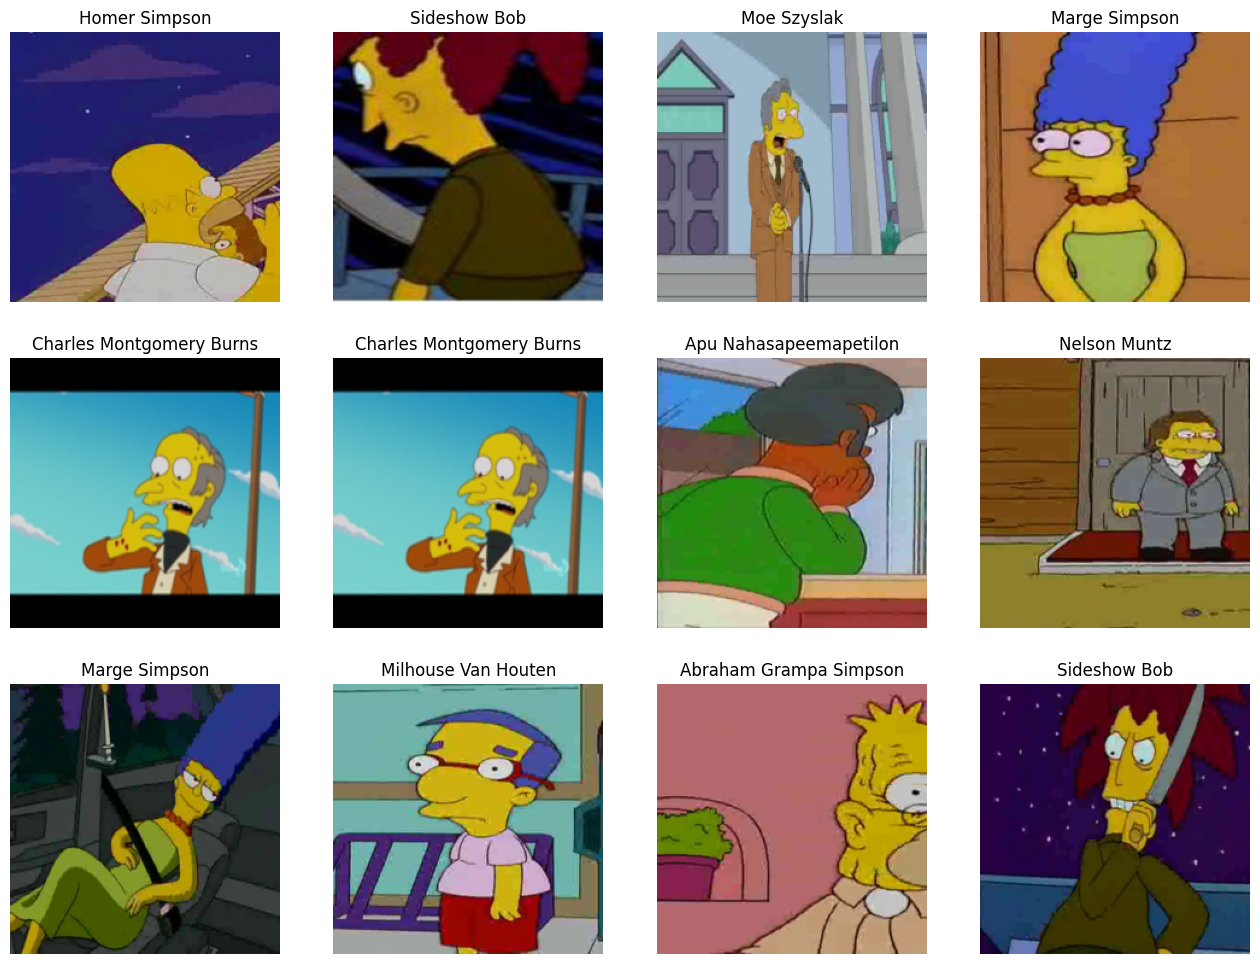

In [18]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

## Шаг 3. Построение нейросети

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [60]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
# torchsummary.summary(model_simple_cnn, (3, 224, 224))

SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv5): Sequential(
    (0): Conv2d(64, 96, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (out): Linear(in_features=2400, out_features=42, bias=True)


##Шаг 4. Функции для работы с моделью

#### Задание - напишите функции для работы с моделью

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Ниже приводится код для вычисления целевой метрики.

In [19]:
from sklearn.metrics import f1_score
# пример расчета: f1 = f1_score(actual_labels, y_predicted, average='micro')

В этом задании может быть полезным сделать, чтобы функция валидации и, возможно, функция обучения на одной эпохе возвращали векторы/тензоры:
- предсказанного наиболее вероятного класса
- и фактических меток класса для каждого объекта.

Сама метрика f1, при этом, будет вычисляться не внутри функции, а вне ее, сопоставляя прогнозные и фактические значения, полученные из вывода функции.

Это поможет проанализировать, при предсказании каких классов модель ошибается чаще. Также такой подход может использоваться для обнаружения изображений, которые модель классифицирует неверно.

Для ускорения вычислений рекомендуется при работе с моделью проводить тензорные вычисления на GPU. Обращаем внимание, для этого необходимо, чтобы и данные, и модель находились на одном устройстве.

Ниже представлен код из предыдущего домашнего задания, который демонстрировал логику циклов обучения и валидации. Ниже в этот код добавлены строки комментарии, показывающие как переносить модель и данные на устройство.


```python
model.to(DEVICE)  # <- переносим модель на устройство DEVICE

for epoch in range(max_epochs):  
    # режим train
    model.train()  
    for x_batch, y_batch in train_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()  
        optimizer.step()
        
        count_metrics(outp, y_batch)  # <-здесь, скорее всего, потребуется перенести данные на cpu, например с помощью метода cpu: metrics.cpu()
     
     # режим test/eval
     model.eval()  
     for x_batch, y_batch in val_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        with torch.no_grad():
            outp = model(x_batch)
            count_metrics(outp, y_batch) # <-здесь, скорее всего, потребуется перенести данные на cpu       
```

Напишите функции:
- для обучения модели на одной эпохе
- для валидации модели на одной эпохе
- для реализации полного цикла обучения

За основу можно взять функции, которые вы написали в предыдущем домашнем задании.

В процессе обучения отслеживаем accuracy, а не f1, т.к. её легче интерпретировать.

In [20]:
def fit_one_epoch(model, train_dataloader, optimizer, criterion):
    model.train()

    epoch_metrics = {'loss': 0, 'total_correct': 0, 'total_sample': 0}
    for x_batch, y_batch in tqdm(train_dataloader, desc='обучение') :
        # создаём копии на GPU
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()

        # считаем метрики, для подстраховки отключаем расчёт градиентов
        with torch.no_grad():
            # т.к. количество sample в последнем батче может отличаться, то считаем loss как взвешенное среднее
            epoch_metrics['loss'] += loss.item() * y_batch.size(0)
            epoch_metrics['total_sample'] += y_batch.size(0)
            epoch_metrics['total_correct'] += (outp.argmax(-1) == y_batch).sum().item()

    epoch_metrics['loss'] = epoch_metrics['loss'] / epoch_metrics['total_sample']
    epoch_metrics['accuracy'] = epoch_metrics['total_correct'] / epoch_metrics['total_sample']

    return epoch_metrics

In [21]:
def validate(model, val_dataloader, criterion):
    model.eval()

    epoch_metrics = {'loss': 0, 'total_correct': 0, 'total_sample': 0}
    for x_batch, y_batch in tqdm(val_dataloader, desc='валидация'):
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        # считаем метрики, для подстраховки отключаем расчёт градиентов
        with torch.no_grad():
            outp = model(x_batch)
            loss = criterion(outp, y_batch)
            # т.к. количество sample в последнем батче может отличаться, то считаем loss как взвешенное среднее
            epoch_metrics['loss'] += loss.item() * y_batch.size(0)
            epoch_metrics['total_sample'] += y_batch.size(0)
            epoch_metrics['total_correct'] += (outp.argmax(-1) == y_batch).sum().item()

    epoch_metrics['loss'] = epoch_metrics['loss'] / epoch_metrics['total_sample']
    epoch_metrics['accuracy'] = epoch_metrics['total_correct'] / epoch_metrics['total_sample']

    return epoch_metrics

In [22]:
def train(model, dataloader, optimizer, criterion, epochs):
    train_metrics = []
    val_metrics = []
    best_val_metric = 0
    checkpoint = 1

    # Формируем имя модели и путь для сохранения
    lr = optimizer.defaults['lr']
    weight_decay = optimizer.defaults['weight_decay']
    batch_size = dataloader['train'].batch_size
    model_name = f'{type(model).__name__}_{epochs}_{type(optimizer).__name__}_{batch_size}_{lr}_{weight_decay}'
    path = Path(f'/content/results/{model_name}')

    if path.is_dir():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, epochs + 1):
        print(f'Эпоха № {epoch}')

        fit_metrics = fit_one_epoch(model, dataloader['train'], optimizer, criterion)
        print(f'fit_loss: {fit_metrics['loss']:.3f}\nfit_accuracy: {fit_metrics['accuracy']:.3f}')
        train_metrics.append(fit_metrics)

        validate_metrics = validate(model, dataloader['val'], criterion)
        print(f'validate_loss: {validate_metrics['loss']:.3f}\nvalidate_accuracy: {validate_metrics['accuracy']:.3f}\n')
        val_metrics.append(validate_metrics)

        if validate_metrics['accuracy'] > best_val_metric:
            best_val_metric = validate_metrics['accuracy']
            torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'fit_loss': fit_metrics['loss'],
                        'fit_accuracy': fit_metrics['accuracy'],
                        'validate_loss': validate_metrics['loss'],
                        'validate_accuracy': validate_metrics['accuracy']
                        }, path / f'checkpoint_{checkpoint}.tar')
            checkpoint += 1

    # cохраняем метрики в CSV
    pd.DataFrame(train_metrics).to_csv(path / 'train_metrics.csv')
    pd.DataFrame(val_metrics).to_csv(path / 'val_metrics.csv')

    shutil.make_archive(model_name, 'zip', path)
    google.colab.files.download(f'{model_name}.zip')


## Шаг 5. Применение модели к данным

#### Применение модели к данным

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
criterion = nn.CrossEntropyLoss()
# используем оптимизатор AdamW
optimizer = torch.optim.AdamW(model_simple_cnn.parameters())

Запустите обучение сети

In [ ]:
train(model_simple_cnn, loaders, optimizer, criterion, epochs=5)

Эпоха № 1


обучение: 100%|██████████| 246/246 [01:58<00:00,  2.07it/s]


fit_loss: 2.536
fit_accuracy: 0.292


валидация: 100%|██████████| 82/82 [00:38<00:00,  2.11it/s]


val_loss: 1.887
val_accuracy: 0.493
Эпоха № 2


...

fit_loss: 0.575
fit_accuracy: 0.835


валидация: 100%|██████████| 82/82 [00:37<00:00,  2.18it/s]


val_loss: 1.058
val_accuracy: 0.738


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(опционально) Постройте график динамики метрик модели по ходу обучения

Напишем класс для построения графиков

In [44]:
class Figure:

    fontdict_suptitle = {
        'fontstyle': 'italic',
        'fontweight': 'bold',
        'fontsize': 17
    }

    fontdict_ax_labels = {
        'fontstyle': 'italic',
        'fontsize': 13
    }

    fontdict_ax_title = {
        'fontstyle': 'italic',
        'fontsize': 15
    }

    def __init__(self, nrows=1, ncols=1, figsize=None, suptitle: str=None):
        self.count = 1
        self.nrows = nrows
        self.ncols = ncols
        self.figsize = figsize
        self.suptitle = suptitle
        self.fig = plt.figure(figsize=self.figsize)
        self.axes = []

    def add_axis(self, *args, title=None, xlabel='x', ylabel='y', grid=True, legend=True):
        if self.count > self.nrows * self.ncols:
            raise ValueError('место для новых осей закончилось')

        ax = self.fig.add_subplot(self.nrows, self.ncols, self.count)
        self.axes.append(ax)
        self.count += 1

        for x, y, label in args:
            ax.plot(x, y, label=label)

        ax.set_xlabel(xlabel, **self.fontdict_ax_labels)
        ax.set_ylabel(ylabel, **self.fontdict_ax_labels)
        ax.set_title(title, **self.fontdict_ax_title)

        if grid:
            ax.grid()
        if legend:
            ax.legend()

    def __repr__(self):
        if self.suptitle:
            return self.suptitle
        return 'без названия'

    def __call__(self):
        if  self.suptitle:
            self.fig.suptitle(self, **self.fontdict_suptitle)

        self.fig.tight_layout()
        return self.fig.show()

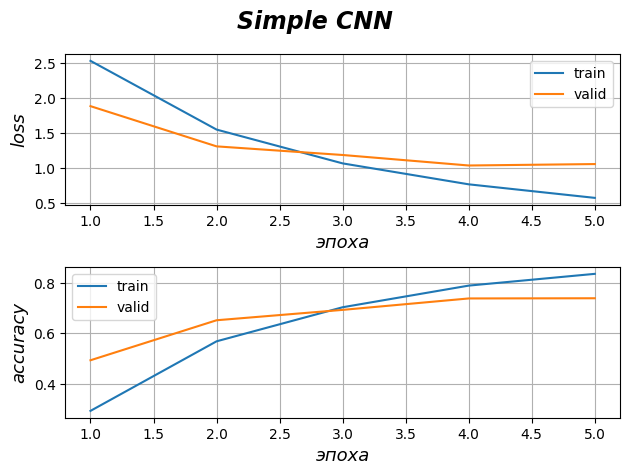

In [ ]:
train_metrics = pd.read_csv('/content/train_metrics.csv', index_col=0)
val_metrics = pd.read_csv('/content/val_metrics.csv', index_col=0)

SimpleCNN_results = Figure(2, 1, suptitle='Simple CNN')

SimpleCNN_results.add_axis((train_metrics.index + 1, train_metrics['loss'], 'train'),
                           (val_metrics.index + 1, val_metrics['loss'], 'valid'),
                           xlabel='эпоха', ylabel='loss')

SimpleCNN_results.add_axis((train_metrics.index + 1, train_metrics['accuracy'], 'train'),
                           (val_metrics.index + 1, val_metrics['accuracy'], 'valid'),
                           xlabel='эпоха', ylabel='accuracy')
SimpleCNN_results()

Видно, что после 3 эпохи начинается переобучение.

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах.

In [24]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = f"Actual : {img_label}"


    font0 = FontProperties()
    font = font0.copy()

    # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = f"{predicted_label}:\n {predicted_proba:.1f}%"

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

Импортируем модель

In [61]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
optimizer = torch.optim.AdamW(model_simple_cnn.parameters())

checkpoint = torch.load('/content/checkpoint_4.tar', weights_only=True, map_location=torch.device('cpu'))
model_simple_cnn.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])


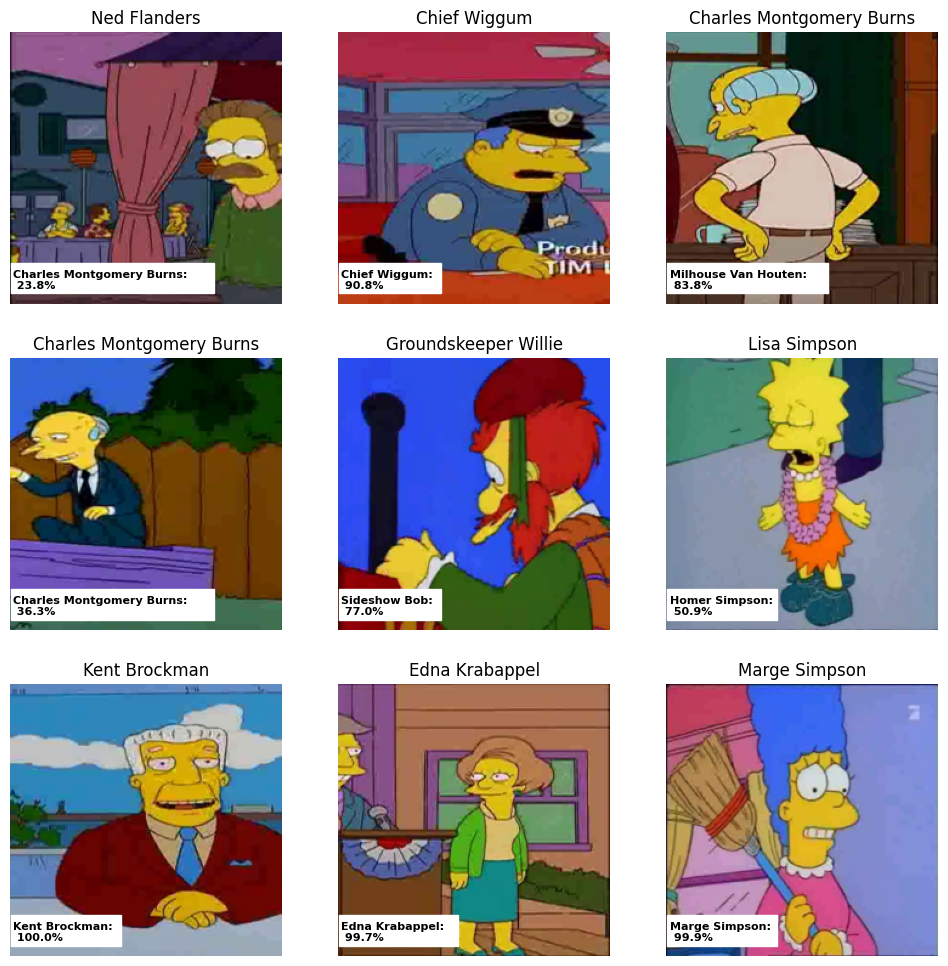

In [ ]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

## Шаг 6. Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

Создадим loader для тестовых данных

In [55]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [51]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")

    for inputs in tqdm_notebook(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)
            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)

    return all_predictions.cpu()

Получем предсказание меток классов для тестовых данных:

In [ ]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

и преобразуем их в текстовые метки:

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle (проверьте путь, по которому у вас лежит файл sample_submission.csv и при необходимости скорректируйте путь в коде ниже):

In [ ]:
import pandas as pd
sample_submission = pd.read_csv("/content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,lisa_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,principal_skinner
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [ ]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут)

In [ ]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся score нас явно не устраивает. Надо с этим что-то сделать.

Вам предлагается творческая и исследовательская свобода в том, как вы будете улучшать score модели. Вот некоторые направления, которые вы, возможно, захотите попробовать:
1. Работа с датасетом:
* Попробуйте увеличить разнообразие обучающей выборки при помощи аугментации ([ссылка 1](https://habr.com/ru/companies/smartengines/articles/264677/), [ссылка 2](https://www.geeksforgeeks.org/python-data-augmentation/));
* Используя результаты функции eval_one_epoch, вы можете посмотреть, как метрика f1-score внутри класса связана с размером самого класса в обучающей выборке. Скорее всего, вы заметите прямую зависимость. Решением может быть увеличение размеров слабо представленных классов. Сделать это можно, вручную добавив этот функционал в SimpsonsDataset или воспользовавшись инструментом WeightedRandomSampler.

* Также вы можете изучить, какие изображения модель классифицирует неверно. Можно просто посмотреть неверно классифицированные изображения в валидационном датасете. Можно попробовать более фундаментальный подход - создать dataloader из всех изображений обучающей и валидационной выборки в SimpsonsDataset c режимом 'val', прогнать данные через обученную модель simple_cnn. Более того, можно обучить несколько моделей с разной архитектурой, и прогнать объединенный датасет через все эти модели - и выделить те изображения, в классификации которых ошиблись несколько моделей.

* Это поможет понять, как качество и чистота исходных данных влияет на результаты обучения модели. Если вы обнаружите ошибки в simpsons_dataset и решите их исправить или удалить некоторые изображения из обучающей выборки - сделайте это в ноутбуке, чтобы при проверке можно было повторить результаты работы вашего кода.  

2. Работа с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных и полносвязных слоёв;
* А еще есть где пулинги и батч-норм!

3. Применение техник, описанных в предыдущих пунктах, позволяет добиться довольно высоких результатов. Но вы можете попробовать файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

4. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

5. Наконец, возможно, стоит подумать об ансамблях


Надеюсь, что у Вас получится!

## Шаг 7. Работа с датасетом

### Изучим какие изображения модель классифицирует неверно

In [25]:
all_dataset = SimpsonsDataset(train_val_files, label_encoder, mode='val')
all_loader = DataLoader(all_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

In [62]:
def miss_class(model: nn.Module,
               val_dataloader: DataLoader,
               label_encoder: LabelEncoder) -> pd.DataFrame:
    """
    Вычисляет accuracy классификации по каждому классу.

    Args:
        model: обученная модель.
        val_dataloader: DataLoader со всеми данными датасета.
        label_encoder: LabelEncoder для преобразования индексов в метки классов.

    Returns:
        DataFrame с колонками: total_sample, total_correct, accuracy.
    """

    model.eval()

    # создаём датафрейм для сбора статистики
    columns = ['total_sample', 'total_correct', 'accuracy']
    index = label_encoder.transform(label_encoder.classes_)
    miss_classes = pd.DataFrame(0, index=index, columns=columns)

    for x_batch, y_batch in tqdm(val_dataloader, desc='валидация'):
        x_batch = x_batch.to(DEVICE)

        # считаем метрики, для подстраховки отключаем расчёт градиентов
        with torch.no_grad():
            outp = model(x_batch)
            y_pred = outp.argmax(-1).cpu()

            # сколько раз встретился класс
            classes, counts = y_batch.unique(return_counts=True)
            classes, counts = classes.numpy(), counts.numpy()
            miss_classes.loc[classes, 'total_sample'] += counts

            # сколько раз правильно определили класс
            is_correct = (y_batch == y_pred)
            corrects = y_pred[is_correct]
            corrects, counts = corrects.unique(return_counts=True)
            corrects, counts = corrects.numpy(), counts.numpy()
            miss_classes.loc[corrects, 'total_correct'] += counts

    miss_classes['accuracy'] = miss_classes['total_correct'] / miss_classes['total_sample']
    miss_classes.index = label_encoder.inverse_transform(miss_classes.index)

    return miss_classes

In [63]:
# miss_classes = miss_class(model_simple_cnn, all_loader, label_encoder)
miss_classes = pd.read_csv('/content/miss_classes.csv', index_col=0)
miss_classes.sort_values(by=['accuracy'], ascending=False, inplace=True)
# miss_classes.to_csv('miss_classes.csv')
miss_classes

,total_sample,total_correct,accuracy
troy_mcclure,8,8,1.000000
krusty_the_clown,1206,1161,0.962687
kent_brockman,498,468,0.939759
sideshow_bob,877,801,0.913341
marge_simpson,1291,1175,0.910147
apu_nahasapeemapetilon,623,559,0.897271
milhouse_van_houten,1079,967,0.896200
ned_flanders,1454,1302,0.895461
patty_bouvier,72,60,0.833333
lisa_simpson,1354,1128,0.833087


Сделаем визуализацию

In [64]:
def my_barh(data, figsize=None):

    accuracy = data['accuracy'].values
    total_sample = data['total_sample'].values
    labels = data.index
    y_ticks = np.arange(len(labels))
    height = 0.4

    fig, ax1 = plt.subplots(figsize=figsize)
    ax1.set_yticks(y_ticks + height / 2, labels=labels)
    ax1.set_ylim(bottom=-height, top=len(y_ticks))
    ax1.set_xlim(left=0.45)
    ax2 = ax1.twiny()

    b1 = ax1.barh(y=y_ticks, width=accuracy, height=height, label='accuracy')
    ax1.bar_label(b1, fmt='%.2f')

    b2 = ax2.barh(y=y_ticks + height, width=total_sample, height=height, color='red', label='количество')
    ax2.bar_label(b2)

    # делаем легенду
    handles = [b1, b2]
    ax1.legend(handles=handles, labels=map(lambda x: x.get_label(), handles))

    fig.show()

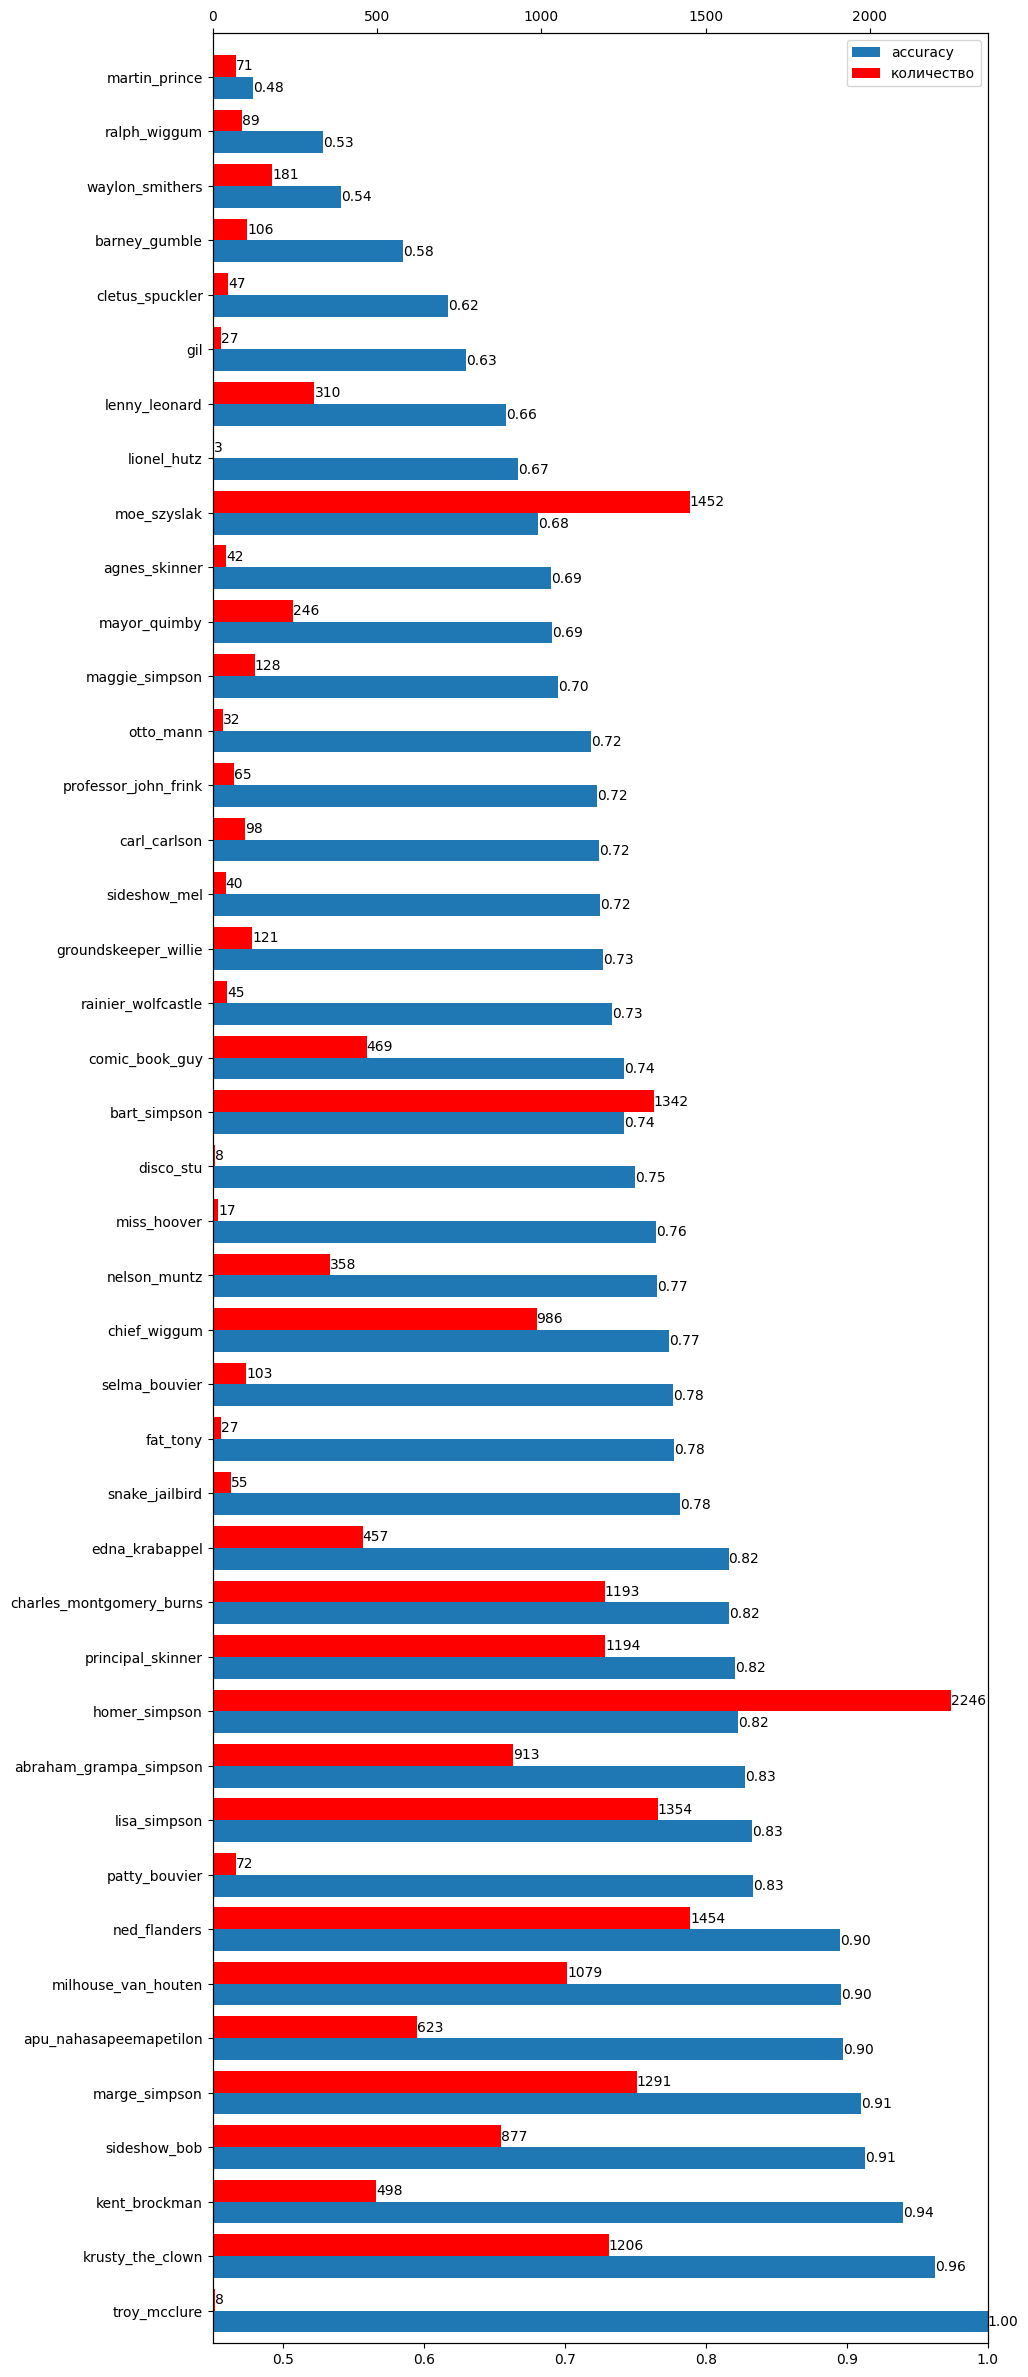

In [65]:
my_barh(miss_classes, figsize=(10, 30))

1.   В общем и целом видим, что чем больше количество экземпляров, тем лучше классификация (начиная с edna_krabappel красные столбцы занимают всё большее пространство) --> будем генерировать дополнительные изображения с помощью аугментаций:

```python
v2.RandomResizedCrop(size=source_size, scale=(0.7, 1)),
v2.RandomRotation(degrees=10),
v2.RandomPosterize(bits=4),
```
Генерируем картинки, пока каждого класса будет не менее 200 штук.


2.   Тем не менее есть метки, которые широко представлены (moe, bart_simpson, chief_wiggum), но качество классификации не очень --> возможно дело в переобучении, поэтому будем применять ко всем картинкам дополнительные аугментации, чтобы улучшить обобщающую способность:

```python
v2.RandomHorizontalFlip(p=0.5),
v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1)
```










### Доработка кастомного класса

Доработаем наш класс `SimpsonsDataset`, чтобы он:


1.   При формировании train-датасета автоматически генерировал с помощью аугментаций новые картинки для слабо представленных классов (если их менее 200). Аугментировать можно только имеющиеся в train-датасете картинки, чтобы не было утечки данных. Размер картинок остаётся текущим.

Причём при создании нового датасета все ранее сгенерированные картинки должны удаляться.

2. Применял дополнительные аугментации при к картинкам при обучении.



In [28]:
class NewSimpsonsDataset(SimpsonsDataset):

    _generated_files = []

    def __new__(cls, *args, **kwargs):
        # чтобы не плодить много файлов, удаляем их
        if cls._generated_files:
            for path in cls._generated_files:
                path.unlink()

        cls._generated_files.clear()

        return super().__new__(cls)

    def __init__(self, files, label_encoder, mode, min_size: int=200):
        """
        min_size - минимальный размер образцов таргета
        """
        super().__init__(files, label_encoder, mode)
        if self.mode == 'train':
            self.min_size = min_size
            self._generated_files = self._gen_files()
            self.files = sorted(files + self._generated_files)
            self.len_ = len(self.files)


    def _gen_files(self) -> list:
        """
        генерирует дополнительные данные с помощью аугментаций
        Return:
            list сгенерированных файлов
        """
        # распределяем файлы по персонажам
        persons = defaultdict(list)
        for path in self.files:
            persons[path.parent.name] += [path]

        # генерируем новые картинки и добавляем их в new_files
        new_files = []
        for person, files in persons.items():
            size = len(files)
            while size < self.min_size:
                new_picture = self._gen_new_img(files, size + 1)
                size += 1
                new_files.append(new_picture)

        return new_files

    def _gen_new_img(self, files, idx):
        '''
        генерирует новую картинку на основе существующей
        files: список существующих картинок
        idx: индекс новой картинки

        Return: Path до созданной картинки
        '''
        n = random.randint(0, len(files) - 1)
        src_path = files[n]
        src_img = self.load_image(src_path)
        src_tensor = v2.functional.pil_to_tensor(src_img)
        src_size = src_tensor.size()[1:] # height and width

        transform = v2.Compose([
            v2.RandomResizedCrop(size=src_size, scale=(0.7, 1)),
            v2.RandomRotation(degrees=10),
            v2.RandomPosterize(bits=4)
        ])

        new_tensor = transform(src_tensor)
        new_path = src_path.parent / f'pic_gen_{idx:0>4}.jpg'
        new_img = v2.functional.to_pil_image(new_tensor)
        new_img.save(new_path)

        return new_path

    def transform_images_to_tensors(self, image):
        if self.mode == 'train':
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),

                # добавляем новые аугментации
                v2.RandomHorizontalFlip(p=0.5),
                v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),

                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                v2.Resize(RESCALE_SIZE),
            ])
        else:
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                v2.Resize(RESCALE_SIZE),
            ])

        tensor_transformed = transform(image)
        return(tensor_transformed)

In [31]:
new_train_dataset = NewSimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
new_val_dataset = NewSimpsonsDataset(val_files, label_encoder, mode='val')

batch_size = 64

new_train_loader = DataLoader(new_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2 )
new_val_loader = DataLoader(new_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
loaders = {'train': new_train_loader, 'val': new_val_loader}

### Тестируем модель с обновлённым датасетом

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
criterion = nn.CrossEntropyLoss()
# используем оптимизатор AdamW
optimizer = torch.optim.AdamW(model_simple_cnn.parameters())

In [ ]:
train(model_simple_cnn, loaders, optimizer, criterion, epochs=10)

Эпоха № 1


обучение: 100%|██████████| 299/299 [03:42<00:00,  1.34it/s]


fit_loss: 2.708
fit_accuracy: 0.288


валидация: 100%|██████████| 82/82 [00:37<00:00,  2.17it/s]


validate_loss: 1.791
validate_accuracy: 0.512

Эпоха № 2


...

fit_loss: 0.212
fit_accuracy: 0.939


валидация: 100%|██████████| 82/82 [00:36<00:00,  2.25it/s]


validate_loss: 0.818
validate_accuracy: 0.831



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

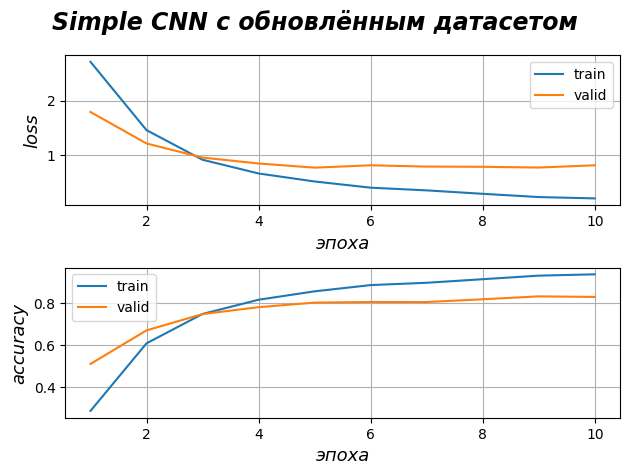

In [ ]:
train_metrics = pd.read_csv('/content/train_metrics.csv', index_col=0)
val_metrics = pd.read_csv('/content/val_metrics.csv', index_col=0)

SimpleCNN_results = Figure(2, 1, suptitle='Simple CNN с обновлённым датасетом')

SimpleCNN_results.add_axis((train_metrics.index + 1, train_metrics['loss'], 'train'),
                           (val_metrics.index + 1, val_metrics['loss'], 'valid'),
                           xlabel='эпоха', ylabel='loss')

SimpleCNN_results.add_axis((train_metrics.index + 1, train_metrics['accuracy'], 'train'),
                           (val_metrics.index + 1, val_metrics['accuracy'], 'valid'),
                           xlabel='эпоха', ylabel='accuracy')
SimpleCNN_results()

Результаты лучше.

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
optimizer = torch.optim.AdamW(model_simple_cnn.parameters())

checkpoint = torch.load('/content/checkpoint_7.tar', weights_only=True, map_location=torch.device('cpu'))
model_simple_cnn.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

predicted_numeric_labels = predict(model_simple_cnn, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.to_csv('simple_cnn__new_dataset.csv', index=False)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

На kaggle f1-score равен 0.9.

In [ ]:
miss_classes = miss_class(model_simple_cnn, all_loader, label_encoder)
miss_classes.sort_values(by=['accuracy'], ascending=False, inplace=True)
miss_classes.to_csv('miss_classes.csv')
# miss_classes = pd.read_csv('/content/miss_classes.csv', index_col=0)
miss_classes

валидация: 100%|██████████| 328/328 [08:26<00:00,  1.55s/it]


,total_sample,total_correct,accuracy
troy_mcclure,8,8,1.000000
ned_flanders,1454,1412,0.971114
apu_nahasapeemapetilon,623,605,0.971108
milhouse_van_houten,1079,1042,0.965709
patty_bouvier,72,69,0.958333
marge_simpson,1291,1229,0.951975
principal_skinner,1194,1130,0.946399
krusty_the_clown,1206,1138,0.943615
chief_wiggum,986,927,0.940162
homer_simpson,2246,2097,0.933660


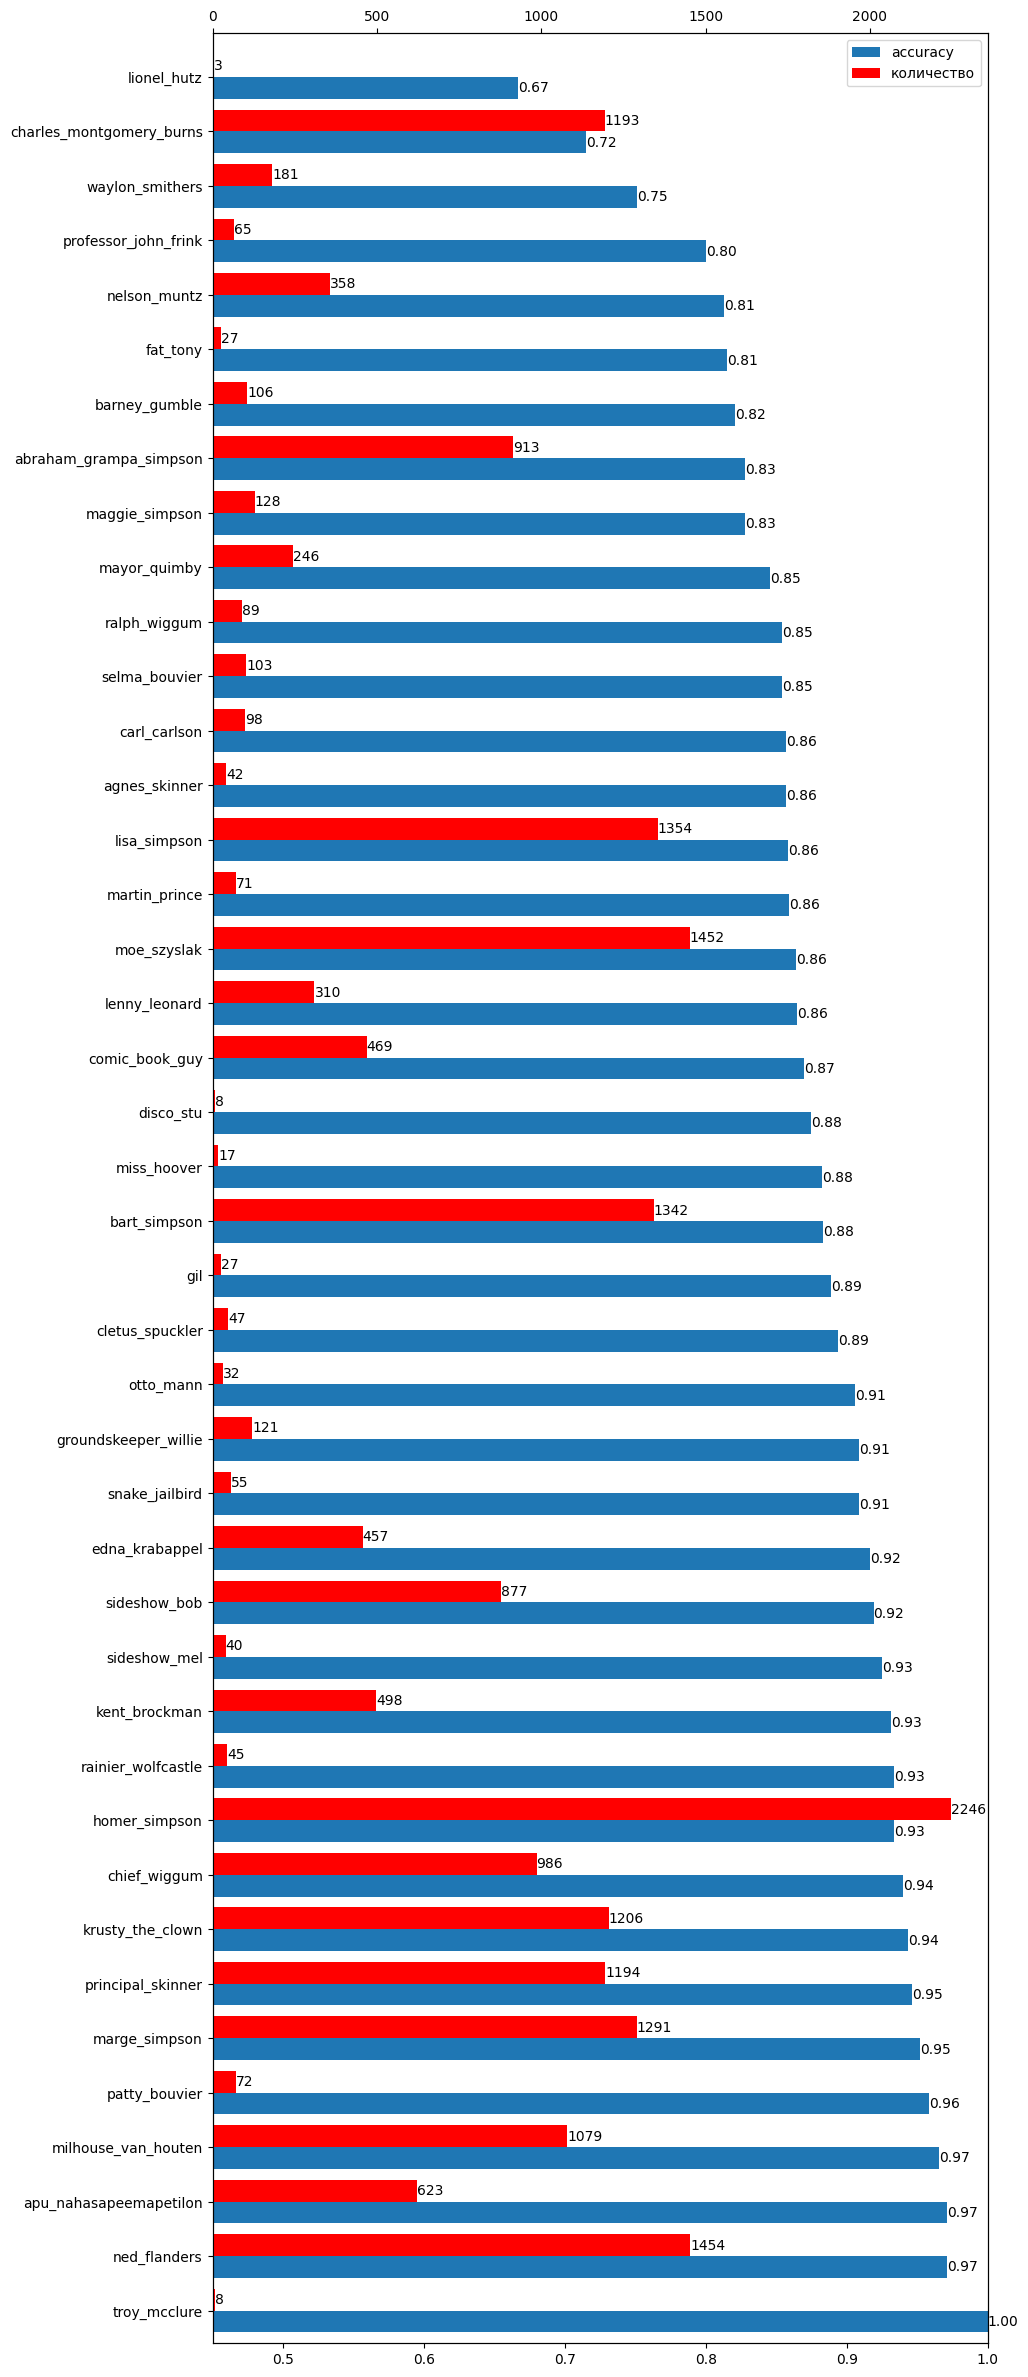

In [ ]:
my_barh(miss_classes, figsize=(10, 30))

Возможно стоит даже сделать более агрессивные модификации датасета, т.к. есть частовстречающиеся классы (мистер Burns, дедушка симпсон) с не очень высокой точностью.

Также можно попробовать увеличить число слабопредставленных классов до 300 штук (вместо 200)

## Шаг 8. Работа с ResNet-18

В этом шаге попробуем использовать transfer learning. Начнём (а может и закончим) с ResNet-18. Попробуем дообучить:

*   только классификатор
*   классификатор и пару последних слоёв

На вход ResNet18 поступает изображение 224 на 224, скалированное от 0 до 1 и нормализованное с такими же средним и стандартным отклонением, как и у нас. Таким образом размеры картинок и диапазон чисел, которые подавались на вход ResNet18, совпадают с нашими.

### Дообучение только классификатора

In [34]:
# Загружаем модель
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_resnet18.fc.in_features

# Замораживаем слои
for param in model_resnet18.parameters():
    param.requires_grad = False

# по умолчанию у новых слоёв requires_grad = True
model_resnet18.fc = nn.Linear(num_ftrs, len(np.unique(train_val_labels)))
model_resnet18.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_resnet18.fc.parameters())

model_resnet18

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [35]:
train(model_resnet18, loaders, optimizer, criterion, epochs=4)

Эпоха № 1


обучение: 100%|██████████| 299/299 [03:40<00:00,  1.36it/s]


fit_loss: 2.238
fit_accuracy: 0.463


валидация: 100%|██████████| 82/82 [00:39<00:00,  2.06it/s]


validate_loss: 1.424
validate_accuracy: 0.671

Эпоха № 2


...

fit_loss: 0.900
fit_accuracy: 0.773


валидация: 100%|██████████| 82/82 [00:39<00:00,  2.07it/s]


validate_loss: 0.959
validate_accuracy: 0.747



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

По логам видим, что качество ухудшилось.

### Дообучение классификатора и последних слоёв

Есть гипотеза, что поскольку картинки Симпсонов и IamgeNet отличаются, то надо обучать ещё и последние свёрточные слои. Первые свёрточные слои выделяют общие простые паттерны, поэтому их не трогаем.

In [25]:
# загружаем модель
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_resnet18.fc.in_features

# замораживаем слои кроме заданных 'fc', 'layer4', 'layer3'
unfreezy_layers = ('fc', 'layer4', 'layer3')
for name, param in model_resnet18.named_parameters():
    if not name.startswith(unfreezy_layers):
        param.requires_grad = False

# по умолчанию у новых слоёв requires_grad = True
model_resnet18.fc = nn.Linear(num_ftrs, len(np.unique(train_val_labels)))
model_resnet18.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda x: x[0].startswith(unfreezy_layers),
                                     model_resnet18.named_parameters()))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


In [27]:
train(model_resnet18, loaders, optimizer, criterion, epochs=12)

Эпоха № 1


обучение: 100%|██████████| 299/299 [03:40<00:00,  1.36it/s]


fit_loss: 0.514
fit_accuracy: 0.871


валидация: 100%|██████████| 82/82 [00:38<00:00,  2.14it/s]


validate_loss: 0.332
validate_accuracy: 0.916

Эпоха № 2


...

fit_loss: 0.062
fit_accuracy: 0.983


валидация: 100%|██████████| 82/82 [00:40<00:00,  2.03it/s]


validate_loss: 0.198
validate_accuracy: 0.960



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Уже по логам видим, что результаты сильно улучшились

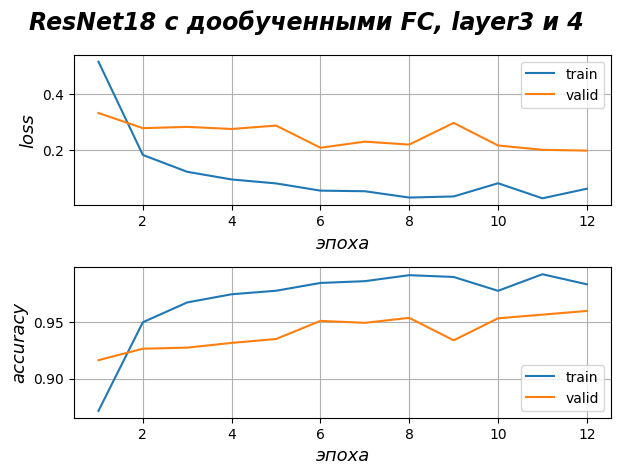

In [32]:
train_metrics = pd.read_csv('/content/train_metrics.csv', index_col=0)
val_metrics = pd.read_csv('/content/val_metrics.csv', index_col=0)

ResNet18_results = Figure(2, 1, suptitle='ResNet18 c дообученными FC, layer3 и 4')

ResNet18_results.add_axis((train_metrics.index + 1, train_metrics['loss'], 'train'),
                           (val_metrics.index + 1, val_metrics['loss'], 'valid'),
                           xlabel='эпоха', ylabel='loss')

ResNet18_results.add_axis((train_metrics.index + 1, train_metrics['accuracy'], 'train'),
                           (val_metrics.index + 1, val_metrics['accuracy'], 'valid'),
                           xlabel='эпоха', ylabel='accuracy')
ResNet18_results()

*   Результаты намного лучше предыдущего.
*   Начиная с 9 эпохи, метрики на train скачут то вверх, то вниз. Возможно, что модель всё время перепрыгивает через минимум и нужно на поздних эпохах уменьшать learning rate.
*   Модель уже после первой эпохи демонстрирует отличные результаты, достигая своего максимума на 6 эпохе.

In [37]:
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, len(np.unique(train_val_labels)))

unfreezy_layers = ('fc', 'layer4', 'layer3')
optimizer = torch.optim.AdamW(filter(lambda x: x[0].startswith(unfreezy_layers),
                                     model_resnet18.named_parameters()))

checkpoint = torch.load('/content/checkpoint_6.tar', weights_only=True, map_location=torch.device('cpu'))
model_resnet18.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

predicted_numeric_labels = predict(model_resnet18, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.to_csv('resnet18.csv', index=False)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

Результат на Kaggle - 0.98193!

In [40]:
miss_classes = miss_class(model_resnet18, all_loader, label_encoder)
# miss_classes = pd.read_csv('/content/miss_classes.csv', index_col=0)
miss_classes.sort_values(by=['accuracy'], ascending=False, inplace=True)
miss_classes.to_csv('miss_classes.csv')
miss_classes

валидация: 100%|██████████| 328/328 [36:57<00:00,  6.76s/it]


,total_sample,total_correct,accuracy
troy_mcclure,8,8,1.000000
bart_simpson,1342,1337,0.996274
krusty_the_clown,1206,1200,0.995025
abraham_grampa_simpson,913,908,0.994524
ned_flanders,1454,1446,0.994498
sideshow_bob,877,872,0.994299
kent_brockman,498,495,0.993976
apu_nahasapeemapetilon,623,619,0.993579
milhouse_van_houten,1079,1072,0.993513
edna_krabappel,457,453,0.991247


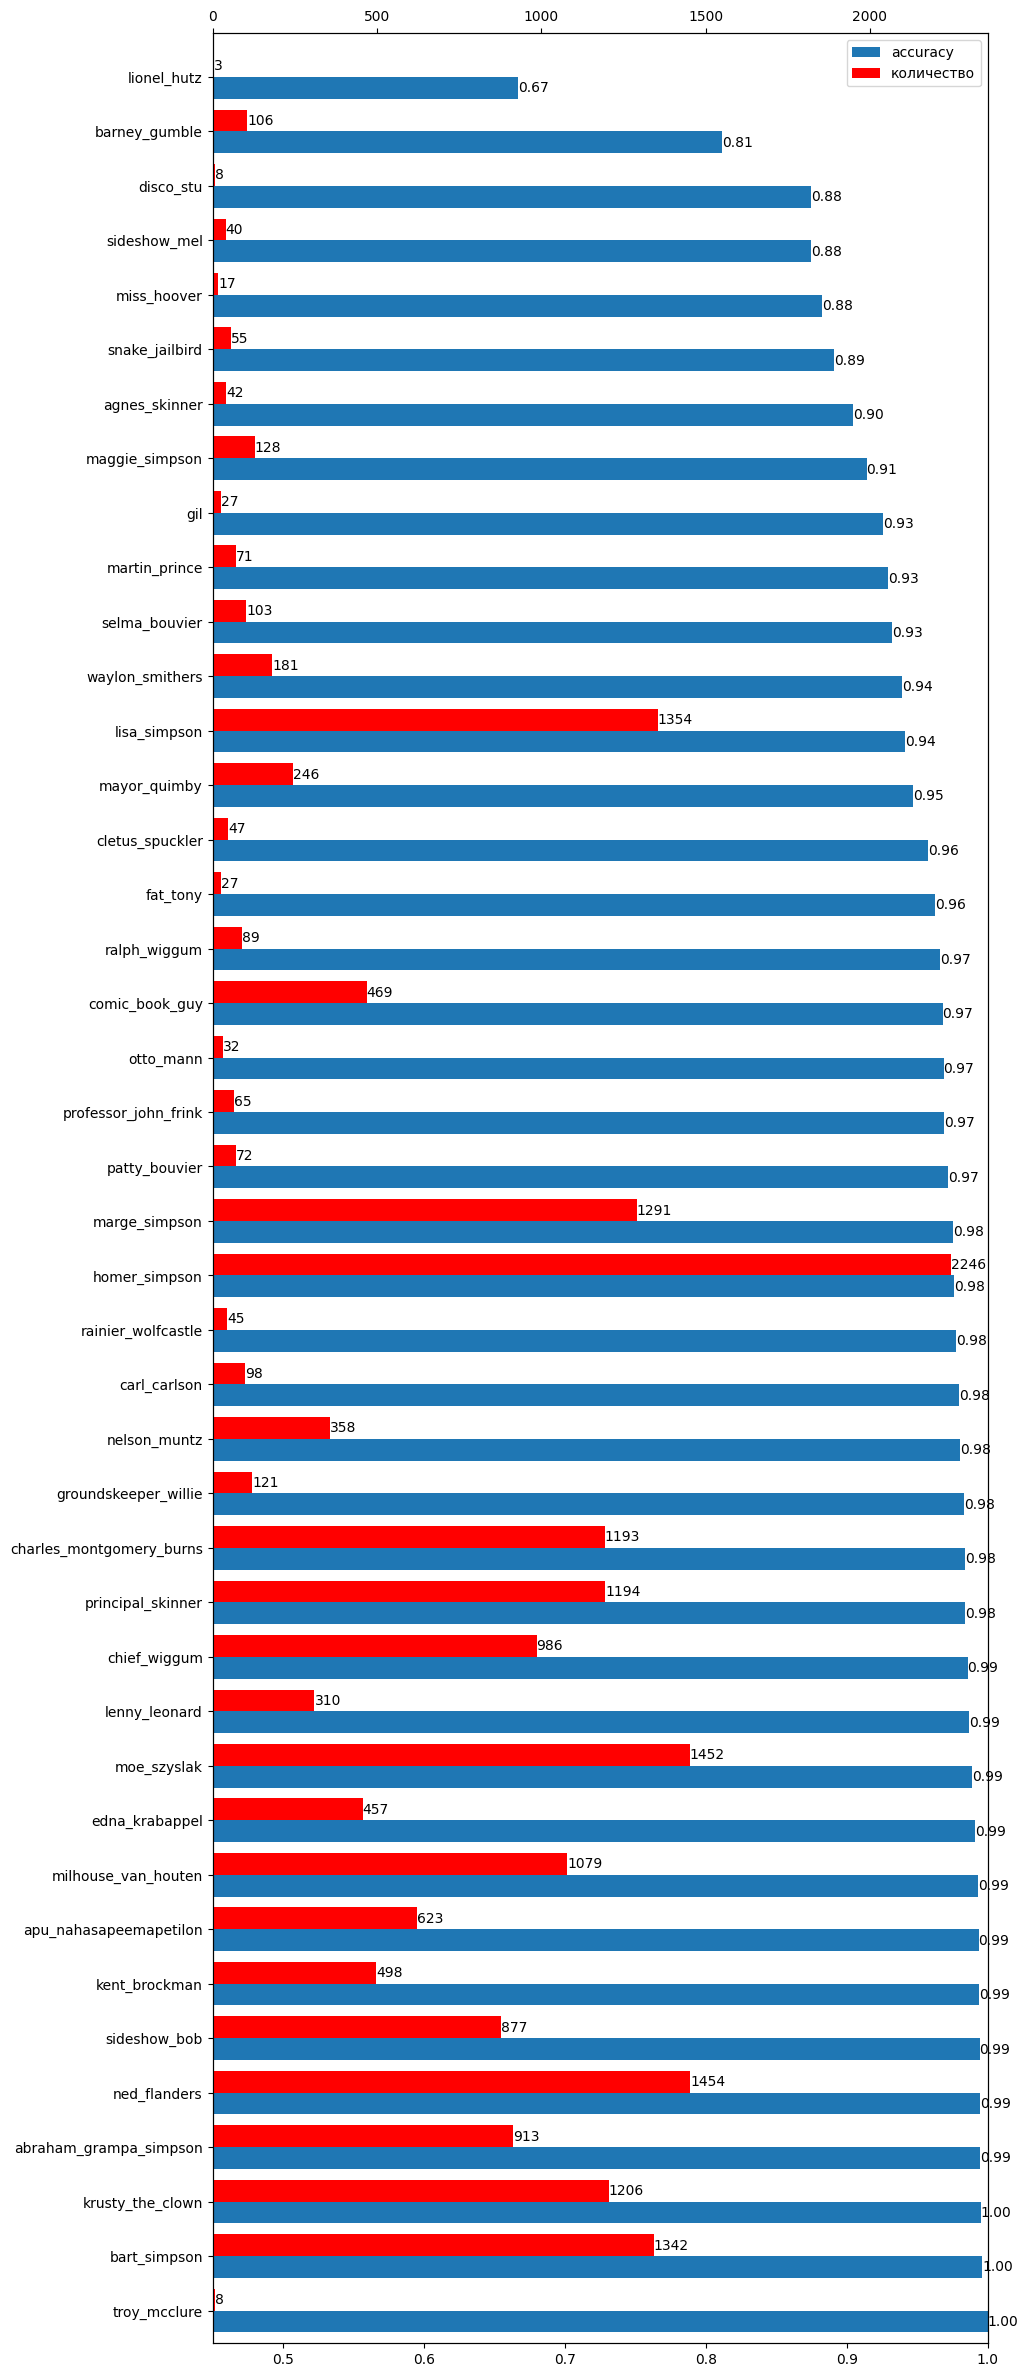

In [41]:
my_barh(miss_classes, figsize=(10, 30))

## Шаг 9. Получение наилучшего результата

В этом шаге попытаемся выжить максимум из модели:

*   Увеличим количество слабопредставленных классов  до 300 штук и применим более агрессивные аугментации датасета:

```python
v2.RandomResizedCrop(size=source_size, scale=(0.7, 0.8)),
v2.RandomRotation(degrees=20),
v2.RandomPosterize(bits=4),
```

```python
v2.RandomHorizontalFlip(p=0.5),
v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2)
```



*   Применим технику learning rate decay (уменьшение шага обучения при увеличении эпохи).

Корректируем наш кастомный датасет

In [34]:
class NewSimpsonsDataset(SimpsonsDataset):

    _generated_files = []

    def __new__(cls, *args, **kwargs):
        # чтобы не плодить много файлов, удаляем их
        if cls._generated_files:
            for path in cls._generated_files:
                path.unlink()
        cls._generated_files.clear()

        return super().__new__(cls)

    def __init__(self, files, label_encoder, mode, min_size: int=300):
        """
        min_size - минимальный размер образцов таргета
        """
        super().__init__(files, label_encoder, mode)
        if self.mode == 'train':
            self.min_size = min_size
            self._generated_files = self._gen_files()
            self.files = sorted(files + self._generated_files)
            self.len_ = len(self.files)

    def _gen_files(self) -> list:
        """
        генерирует дополнительные данные с помощью аугментаций
        Return:
            list сгенерированных файлов
        """
        # распределяем файлы по персонажам
        persons = defaultdict(list)
        for path in self.files:
            persons[path.parent.name] += [path]

        # генерируем новые картинки и добавляем их в new_files
        new_files = []
        for person, files in persons.items():
            size = len(files)
            while size < self.min_size:
                new_picture = self._gen_new_img(files, size + 1)
                size += 1
                new_files.append(new_picture)

        return new_files

    def _gen_new_img(self, files, idx):
        '''
        генерирует новую картинку на основе существующей
        files: список существующих картинок
        idx: индекс новой картинки

        Return: Path до созданной картинки
        '''
        n = random.randint(0, len(files) - 1)
        src_path = files[n]
        src_img = self.load_image(src_path)
        src_tensor = v2.functional.pil_to_tensor(src_img)
        src_size = src_tensor.size()[1:] # height and width

        transform = v2.Compose([
            v2.RandomResizedCrop(size=src_size, scale=(0.7, 0.8)),
            v2.RandomRotation(degrees=20),
            v2.RandomPosterize(bits=4)
        ])

        new_tensor = transform(src_tensor)
        new_path = src_path.parent / f'pic_gen_{idx:0>4}.jpg'
        new_img = v2.functional.to_pil_image(new_tensor)
        new_img.save(new_path)

        return new_path

    def transform_images_to_tensors(self, image):
        if self.mode == 'train':
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),

                # добавляем новые аугментации
                v2.RandomHorizontalFlip(p=0.5),
                v2.ColorJitter(brightness = 0.2, contrast = 0.2, saturation = 0.2),

                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                v2.Resize(RESCALE_SIZE),
            ])
        else:
            transform = v2.Compose([
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                v2.Resize(RESCALE_SIZE),
            ])
        tensor_transformed = transform(image)

        return(tensor_transformed)

In [35]:
new_train_dataset = NewSimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
new_val_dataset = NewSimpsonsDataset(val_files, label_encoder, mode='val')

batch_size = 64

new_train_loader = DataLoader(new_train_dataset, batch_size=batch_size, shuffle=True, num_workers=2 )
new_val_loader = DataLoader(new_val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
loaders = {'train': new_train_loader, 'val': new_val_loader}

Модифицируем функицю train, чтобы использовать sheduler

In [36]:
def train(model, dataloader, optimizer, criterion, epochs, sheduler=None):
    train_metrics = []
    val_metrics = []
    best_val_metric = 0
    checkpoint = 1

    # Формируем имя модели и путь для сохранения
    lr = optimizer.defaults['lr']
    weight_decay = optimizer.defaults['weight_decay']
    batch_size = dataloader['train'].batch_size
    name = type(model).__name__
    opt = type(optimizer).__name__
    opt_shed =  f'{opt}_{type(sheduler).__name__}' if sheduler else opt
    model_name = f'{name}_{epochs}_{opt_shed}_{batch_size}_{lr}_{weight_decay}'
    path = Path(f'/content/results/{model_name}')

    if path.is_dir():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, epochs + 1):
        print(f'Эпоха № {epoch}')

        fit_metrics = fit_one_epoch(model, dataloader['train'], optimizer, criterion)
        print(f'fit_loss: {fit_metrics['loss']:.3f}\nfit_accuracy: {fit_metrics['accuracy']:.3f}')
        train_metrics.append(fit_metrics)

        validate_metrics = validate(model, dataloader['val'], criterion)
        print(f'validate_loss: {validate_metrics['loss']:.3f}\nvalidate_accuracy: {validate_metrics['accuracy']:.3f}\n')
        val_metrics.append(validate_metrics)

        if validate_metrics['accuracy'] > best_val_metric:
            best_val_metric = validate_metrics['accuracy']
            torch.save({
                        'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'fit_loss': fit_metrics['loss'],
                        'fit_accuracy': fit_metrics['accuracy'],
                        'validate_loss': validate_metrics['loss'],
                        'validate_accuracy': validate_metrics['accuracy']
                        }, path / f'checkpoint_{checkpoint}.tar')
            checkpoint += 1

        # добавляем sheduler
        sheduler.step(validate_metrics['loss'])

    # cохраняем метрики в CSV
    pd.DataFrame(train_metrics).to_csv(path / 'train_metrics.csv')
    pd.DataFrame(val_metrics).to_csv(path / 'val_metrics.csv')

    shutil.make_archive(model_name, 'zip', path)
    google.colab.files.download(f'{model_name}.zip')


In [38]:
# загружаем модель
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_resnet18.fc.in_features

# замораживаем слои кроме заданных 'fc', 'layer4', 'layer3'
unfreezy_layers = ('fc', 'layer4', 'layer3')
for name, param in model_resnet18.named_parameters():
    if not name.startswith(unfreezy_layers):
        param.requires_grad = False

# по умолчанию у новых слоёв requires_grad = True
model_resnet18.fc = nn.Linear(num_ftrs, len(np.unique(train_val_labels)))
model_resnet18.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(filter(lambda x: x[0].startswith(unfreezy_layers),
                                     model_resnet18.named_parameters()))

# добавляем шедулер
sheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                       factor = 0.5 , patience=0)

In [40]:
train(model_resnet18, loaders, optimizer, criterion, epochs=15, sheduler=sheduler)

Эпоха № 1


обучение: 100%|██████████| 336/336 [04:10<00:00,  1.34it/s]


fit_loss: 0.498
fit_accuracy: 0.875


валидация: 100%|██████████| 82/82 [00:39<00:00,  2.10it/s]


validate_loss: 0.296
validate_accuracy: 0.923

Эпоха № 2


...

fit_loss: 0.001
fit_accuracy: 1.000


валидация: 100%|██████████| 82/82 [00:39<00:00,  2.10it/s]


validate_loss: 0.133
validate_accuracy: 0.972



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

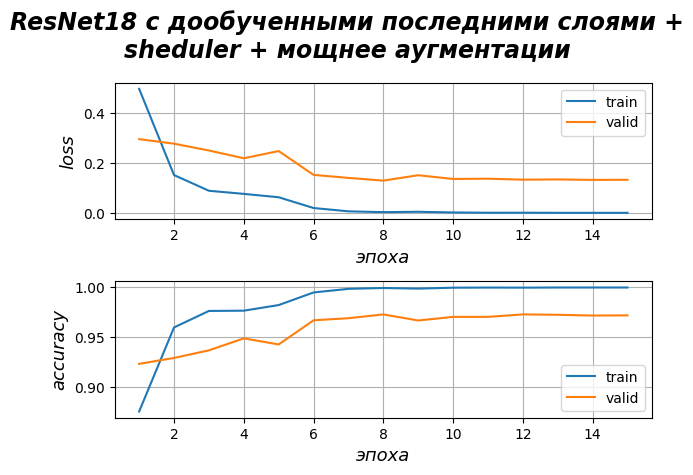

In [48]:
train_metrics = pd.read_csv('/content/results/ResNet_15_AdamW_ReduceLROnPlateau_64_0.001_0.01/train_metrics.csv', index_col=0)
val_metrics = pd.read_csv('/content/results/ResNet_15_AdamW_ReduceLROnPlateau_64_0.001_0.01/val_metrics.csv', index_col=0)

ResNet18_results = Figure(2, 1, suptitle='ResNet18 с дообученными последними слоями +\n\
sheduler + мощнее аугментации')

ResNet18_results.add_axis((train_metrics.index + 1, train_metrics['loss'], 'train'),
                           (val_metrics.index + 1, val_metrics['loss'], 'valid'),
                           xlabel='эпоха', ylabel='loss')

ResNet18_results.add_axis((train_metrics.index + 1, train_metrics['accuracy'], 'train'),
                           (val_metrics.index + 1, val_metrics['accuracy'], 'valid'),
                           xlabel='эпоха', ylabel='accuracy')
ResNet18_results()

In [57]:
model_resnet18 = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = nn.Linear(num_ftrs, len(np.unique(train_val_labels)))

unfreezy_layers = ('fc', 'layer4', 'layer3')
optimizer = torch.optim.AdamW(filter(lambda x: x[0].startswith(unfreezy_layers),
                                     model_resnet18.named_parameters()))
model_resnet18.to(DEVICE)

checkpoint = torch.load('/content/results/ResNet_15_AdamW_ReduceLROnPlateau_64_0.001_0.01/checkpoint_7.tar', weights_only=True)
model_resnet18.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
# sheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
#                                                        factor = 0.5 , patience=0)

predicted_numeric_labels = predict(model_resnet18, test_loader)
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.to_csv('resnet18_with_shed.csv', index=False)
google.colab.files.download('resnet18_with_shed.csv')

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

валидация: 100%|██████████| 328/328 [02:37<00:00,  2.09it/s]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

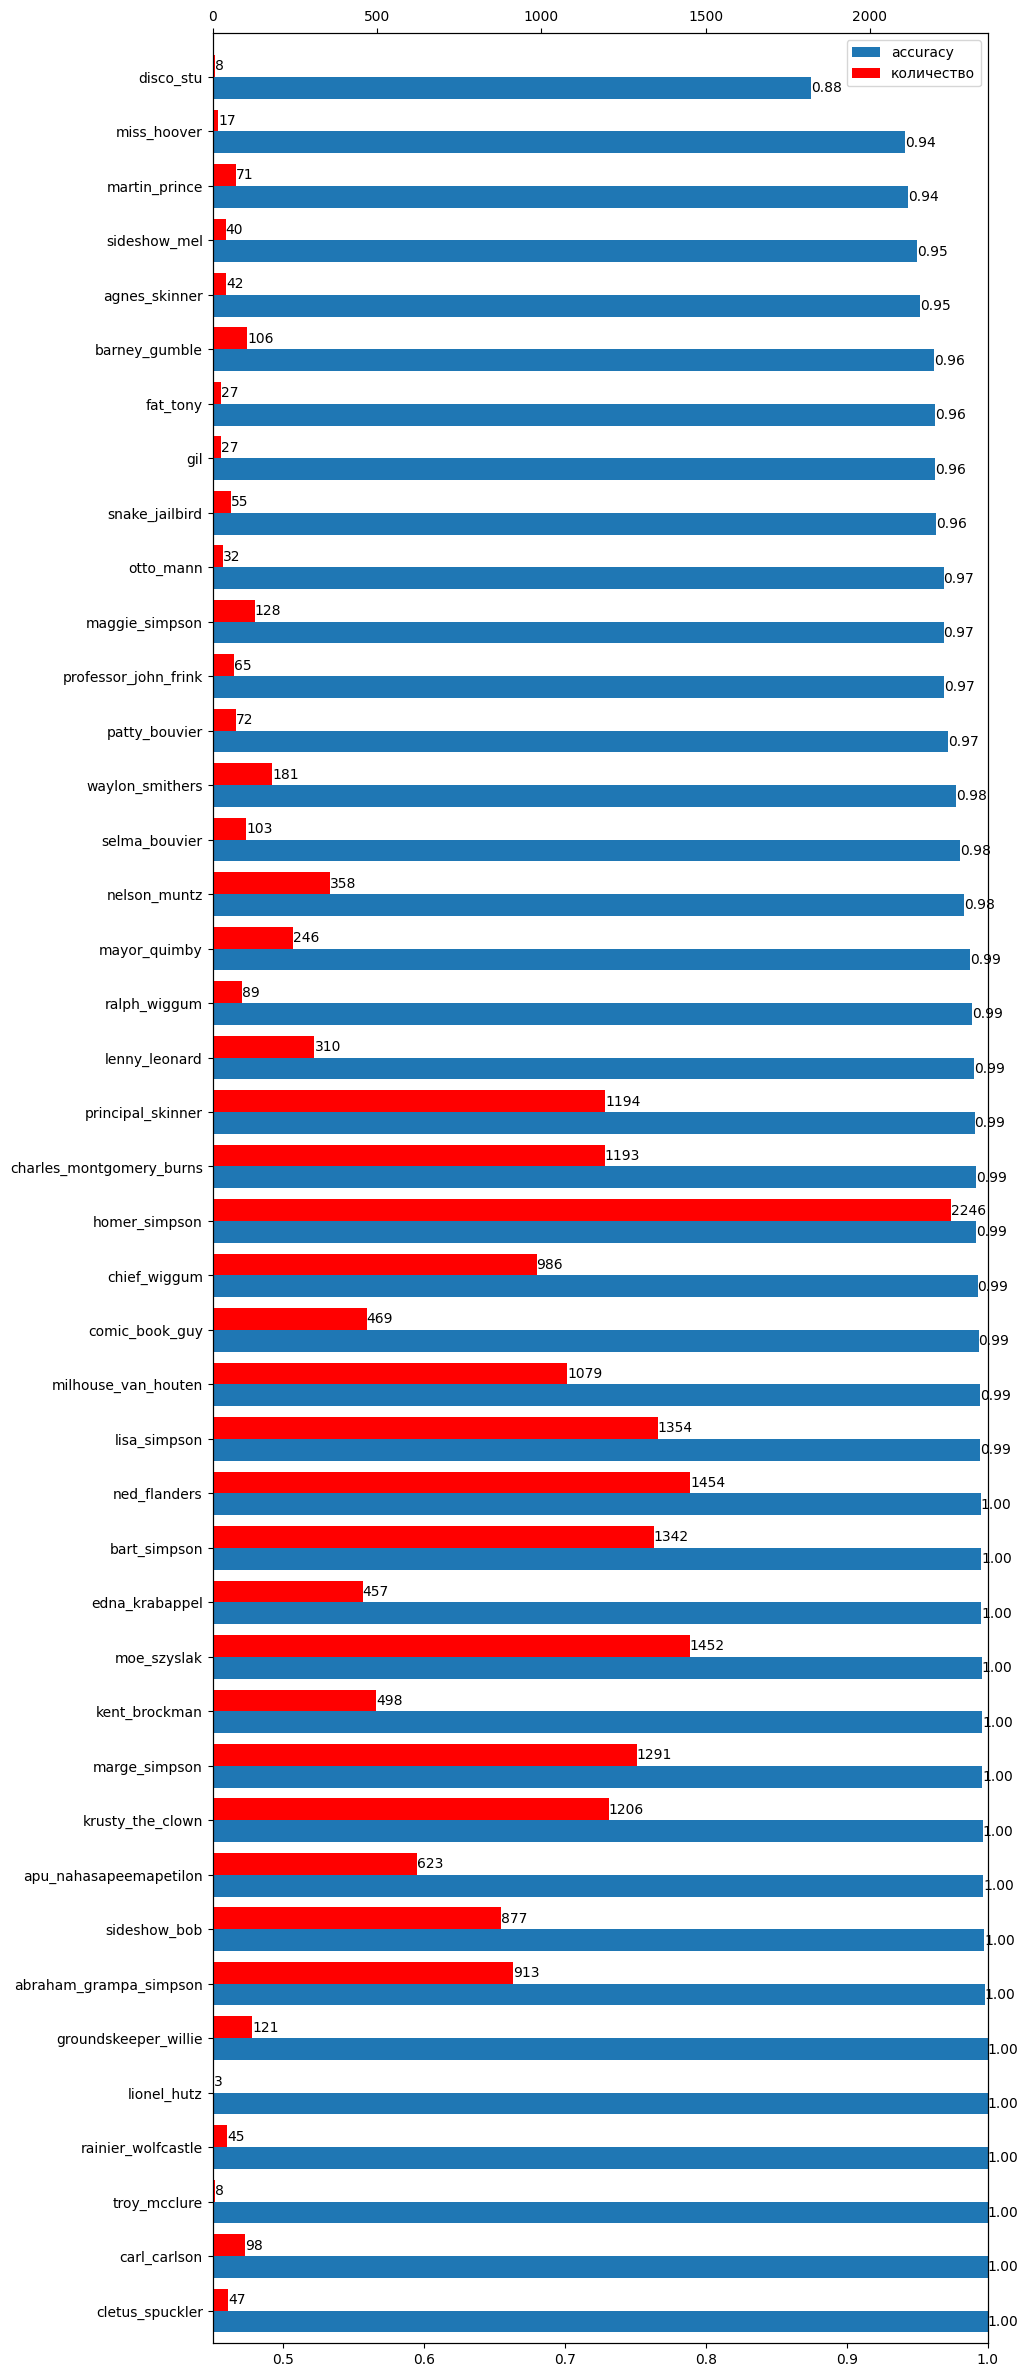

In [58]:
miss_classes = miss_class(model_resnet18, all_loader, label_encoder)
# miss_classes = pd.read_csv('/content/miss_classes.csv', index_col=0)
miss_classes.sort_values(by=['accuracy'], ascending=False, inplace=True)
miss_classes.to_csv('miss_classes.csv')
google.colab.files.download('miss_classes.csv')
my_barh(miss_classes, figsize=(10, 30))

Результат на Kaggle - 0.99681! На этом остановимся.

## Итог

Для достижения наилучшего результата мы:

1.   Искусственно раздули слабопредставленные классы до 300 картинок с помощью аугментаций.
2.   Применяли аугментации ко всем изображениям при обучении.
3.  Дообучили ResNet18: fc-слой, слои в модулях layer3 и layer4.
4.  Применили оптимизатор AdamW совместно с sheduler.

Ник на Kaggle - vasyamba007